# Loading and Cleaning Datasets
Author: Amin Alhawary

In [40]:
import pandas as pd

In [41]:
df_1 = pd.read_csv('/home/amin/stuff/big_data_project/Dataset-AAKTP-Node 1 Baby chick section.csv')
df_2 = pd.read_csv('/home/amin/stuff/big_data_project/Dataset-AAKTP-Node 2 Main-East-Zone.csv')
df_3 = pd.read_csv('/home/amin/stuff/big_data_project/Dataset-AAKTP-Node 3 Main West-Zone.csv')

In [42]:
print(df_1.shape)
display(df_1.head(5))

(85984, 12)


,Time,Temperature,Humidity,Noise-Avg,Noise-Peak,Light,H2S,NH3,NO2,PM2-5,PM10,TVOC
0,01/02/2024 21:22,23,45,50,77,407,1,106,3,7,7,102
1,02/02/2024 9:05,13,69,49,119,4,0,59,4,90,93,98
2,02/02/2024 9:10,13,69,46,49,3,0,59,3,3,3,102
3,02/02/2024 9:15,13,68,46,50,10,0,59,2,0,0,99
4,02/02/2024 9:20,13,68,46,48,13,0,58,2,0,0,100


In [43]:
print(df_2.shape)
display(df_2.head(5))

(80987, 12)


,Time,Temperature,Humidity,Noise-Avg,Noise-Peak,Light,H2S,NH3,NO2,PM2-5,PM10,TVOC
0,01/02/2024 21:31,23,44,53,498,328,0,105,4,8,8,102
1,02/02/2024 10:43,19,56,60,111,704,0,73,3,0,0,102
2,02/02/2024 10:48,19,55,53,87,664,0,71,3,0,0,101
3,02/02/2024 10:53,19,55,51,80,700,0,68,3,1,1,100
4,02/02/2024 10:58,19,54,55,350,703,0,65,3,21,21,100


In [44]:
print(df_3.shape)
display(df_3.head(5))

(87127, 12)


,Time,Temperature,Humidity,Noise-Avg,Noise-Peak,Light,H2S,NH3,NO2,PM2-5,PM10,TVOC
0,07/02/2024 13:55,25,29,211,494,701,1,37,2,2,2,114
1,07/02/2024 15:18,23,31,211,479,459,0,34,2,4,4,85
2,07/02/2024 15:26,24,30,210,473,631,0,34,2,3,3,95
3,07/02/2024 15:51,25,30,231,493,648,0,33,2,4,4,101
4,07/02/2024 15:56,25,29,236,482,612,0,33,2,4,4,106


In [45]:
# Setup for shared data quality checks
import numpy as np


datasets = {
    "Node 1 - Baby chick": df_1.copy(),
    "Node 2 - Main East": df_2.copy(),
    "Node 3 - Main West": df_3.copy(),
}

for name, df in datasets.items():
    # Normalise headers to avoid hidden mismatches from extra spaces
    df.columns = [c.strip() for c in df.columns]
    datasets[name] = df

print("Datasets ready:")
for name, df in datasets.items():
    print(f"- {name}: {df.shape[0]} rows, {df.shape[1]} columns")

Datasets ready:
- Node 1 - Baby chick: 85984 rows, 12 columns
- Node 2 - Main East: 80987 rows, 12 columns
- Node 3 - Main West: 87127 rows, 12 columns


In [46]:
# 1) Assert all columns match names and dtypes across all three datasets
reference_name = list(datasets.keys())[0]
reference_df = datasets[reference_name]
reference_cols = list(reference_df.columns)
reference_dtypes = reference_df.dtypes.astype(str)

print(f"Reference dataset: {reference_name}\n")

for name, df in datasets.items():
    col_match = list(df.columns) == reference_cols
    dtype_compare = pd.DataFrame({
        "reference_dtype": reference_dtypes,
        "current_dtype": df.dtypes.astype(str)
    })
    dtype_compare["dtype_match"] = dtype_compare["reference_dtype"] == dtype_compare["current_dtype"]

    print(f"=== {name} ===")
    print(f"Column order/name match: {col_match}")

    if not col_match:
        missing = sorted(set(reference_cols) - set(df.columns))
        extra = sorted(set(df.columns) - set(reference_cols))
        print("Missing columns:", missing)
        print("Extra columns:", extra)

    if not dtype_compare["dtype_match"].all():
        print("Dtype mismatches:")
        display(dtype_compare[~dtype_compare["dtype_match"]])
    else:
        print("All dtypes match reference.")
    print()

Reference dataset: Node 1 - Baby chick

=== Node 1 - Baby chick ===
Column order/name match: True
All dtypes match reference.

=== Node 2 - Main East ===
Column order/name match: True
All dtypes match reference.

=== Node 3 - Main West ===
Column order/name match: True
All dtypes match reference.



In [47]:
# 2) Check NaNs in numeric columns and empty/missing strings in non-numeric columns
for name, df in datasets.items():
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    other_cols = [c for c in df.columns if c not in numeric_cols]

    numeric_nan_counts = df[numeric_cols].isna().sum().sort_values(ascending=False)

    text_missing_counts = {}
    for col in other_cols:
        series = df[col]
        text_missing_counts[col] = (
            series.isna() |
            series.astype(str).str.strip().eq("") |
            series.astype(str).str.strip().str.lower().isin(["nan", "none", "null", "na", "n/a"])
        ).sum()

    print(f"=== {name} ===")
    print("Numeric NaN counts:")
    display(numeric_nan_counts.to_frame("nan_count"))

    print("Non-numeric missing/empty counts:")
    display(pd.Series(text_missing_counts, name="missing_or_empty_count").to_frame())
    print()

=== Node 1 - Baby chick ===
Numeric NaN counts:


,nan_count
Temperature,0
Humidity,0
Noise-Avg,0
Noise-Peak,0
Light,0
H2S,0
NH3,0
NO2,0
PM2-5,0
PM10,0


Non-numeric missing/empty counts:


,missing_or_empty_count
Time,0


=== Node 2 - Main East ===
Numeric NaN counts:


...

,missing_or_empty_count
Time,0



=== Node 3 - Main West ===
Numeric NaN counts:


,nan_count
Temperature,0
Humidity,0
Noise-Avg,0
Noise-Peak,0
Light,0
H2S,0
NH3,0
NO2,0
PM2-5,0
PM10,0


Non-numeric missing/empty counts:


,missing_or_empty_count
Time,0


There are no missing or empty counts initially.

In [48]:
# 2b) Physical-bound checks (based on researched limits)
# Notes:
# - PM2-5/PM10/TVOC do not have strict universal physical upper bounds, so we only enforce non-negative.
# - For gases, we keep a conservative hard cap for data-quality screening.

physical_bounds = {
    "Temperature": (-273.15, 45),
    "Humidity": (0, 100),
    "Noise-Avg": (0, 140),
    "Noise-Peak": (0, 140),
    "Light": (0, 120000),
    "H2S": (0, 100),
    "NH3": (0, 300),
    "NO2": (0, 20),
    "PM2-5": (0, None),
    "PM10": (0, None),
    "TVOC": (0, None),
}

for name, df in datasets.items():
    print(f"=== {name} ===")

    rows = []
    for col, (low, high) in physical_bounds.items():
        if col not in df.columns:
            continue

        s = pd.to_numeric(df[col], errors="coerce")
        valid = s.notna().sum()

        below_count = int((s < low).sum()) if low is not None else 0
        above_count = int((s > high).sum()) if high is not None else 0
        total_violations = below_count + above_count

        rows.append(
            {
                "column": col,
                "low_bound": low,
                "high_bound": high,
                "valid_values": int(valid),
                "below_low": below_count,
                "above_high": above_count,
                "total_violations": total_violations,
                "violation_pct": round((total_violations / valid) * 100, 3) if valid else np.nan,
            }
        )

    bound_report = pd.DataFrame(rows).sort_values("total_violations", ascending=False)
    display(bound_report)
    print()

=== Node 1 - Baby chick ===


,column,low_bound,high_bound,valid_values,below_low,above_high,total_violations,violation_pct
3,Noise-Peak,0.00,140.0,85984,0,57607,57607,66.997
2,Noise-Avg,0.00,140.0,85984,0,53426,53426,62.135
5,H2S,0.00,100.0,85984,0,29,29,0.034
6,NH3,0.00,300.0,85984,0,1,1,0.001
0,Temperature,-273.15,45.0,85984,0,0,0,0.000
1,Humidity,0.00,100.0,85984,0,0,0,0.000
4,Light,0.00,120000.0,85984,0,0,0,0.000
7,NO2,0.00,20.0,85984,0,0,0,0.000
8,PM2-5,0.00,NaN,85984,0,0,0,0.000
9,PM10,0.00,NaN,85984,0,0,0,0.000



=== Node 2 - Main East ===


,column,low_bound,high_bound,valid_values,below_low,above_high,total_violations,violation_pct
3,Noise-Peak,0.00,140.0,80987,0,4588,4588,5.665
5,H2S,0.00,100.0,80987,0,63,63,0.078
2,Noise-Avg,0.00,140.0,80987,0,8,8,0.010
6,NH3,0.00,300.0,80987,0,7,7,0.009
1,Humidity,0.00,100.0,80987,0,4,4,0.005
0,Temperature,-273.15,45.0,80987,0,0,0,0.000
4,Light,0.00,120000.0,80987,0,0,0,0.000
7,NO2,0.00,20.0,80987,0,0,0,0.000
8,PM2-5,0.00,NaN,80987,0,0,0,0.000
9,PM10,0.00,NaN,80987,0,0,0,0.000



=== Node 3 - Main West ===


,column,low_bound,high_bound,valid_values,below_low,above_high,total_violations,violation_pct
3,Noise-Peak,0.00,140.0,87127,0,35715,35715,40.992
2,Noise-Avg,0.00,140.0,87127,0,34250,34250,39.310
1,Humidity,0.00,100.0,87127,0,1,1,0.001
5,H2S,0.00,100.0,87127,0,1,1,0.001
0,Temperature,-273.15,45.0,87127,0,0,0,0.000
4,Light,0.00,120000.0,87127,0,0,0,0.000
6,NH3,0.00,300.0,87127,0,0,0,0.000
7,NO2,0.00,20.0,87127,0,0,0,0.000
8,PM2-5,0.00,NaN,87127,0,0,0,0.000
9,PM10,0.00,NaN,87127,0,0,0,0.000


In [49]:
# 2c) OPTIONAL: apply physical bounds and convert out-of-bound values to NaN
# Set APPLY_PHYSICAL_BOUNDS = True only when you want to enforce this step.

APPLY_PHYSICAL_BOUNDS = False

if APPLY_PHYSICAL_BOUNDS:
    replacement_summary = []

    for name, df in datasets.items():
        for col, (low, high) in physical_bounds.items():
            if col not in df.columns:
                continue

            s = pd.to_numeric(df[col], errors="coerce")
            mask = pd.Series(False, index=df.index)

            if low is not None:
                mask = mask | (s < low)
            if high is not None:
                mask = mask | (s > high)

            replaced = int(mask.sum())
            if replaced > 0:
                df.loc[mask, col] = np.nan

            replacement_summary.append(
                {
                    "dataset": name,
                    "column": col,
                    "replaced_with_nan": replaced,
                }
            )

    replacement_summary_df = pd.DataFrame(replacement_summary)
    display(replacement_summary_df[replacement_summary_df["replaced_with_nan"] > 0].sort_values(["dataset", "replaced_with_nan"], ascending=[True, False]))
else:
    print("Physical-bound replacement is OFF. Set APPLY_PHYSICAL_BOUNDS = True to apply it.")

Physical-bound replacement is OFF. Set APPLY_PHYSICAL_BOUNDS = True to apply it.


=== Node 1 - Baby chick ===


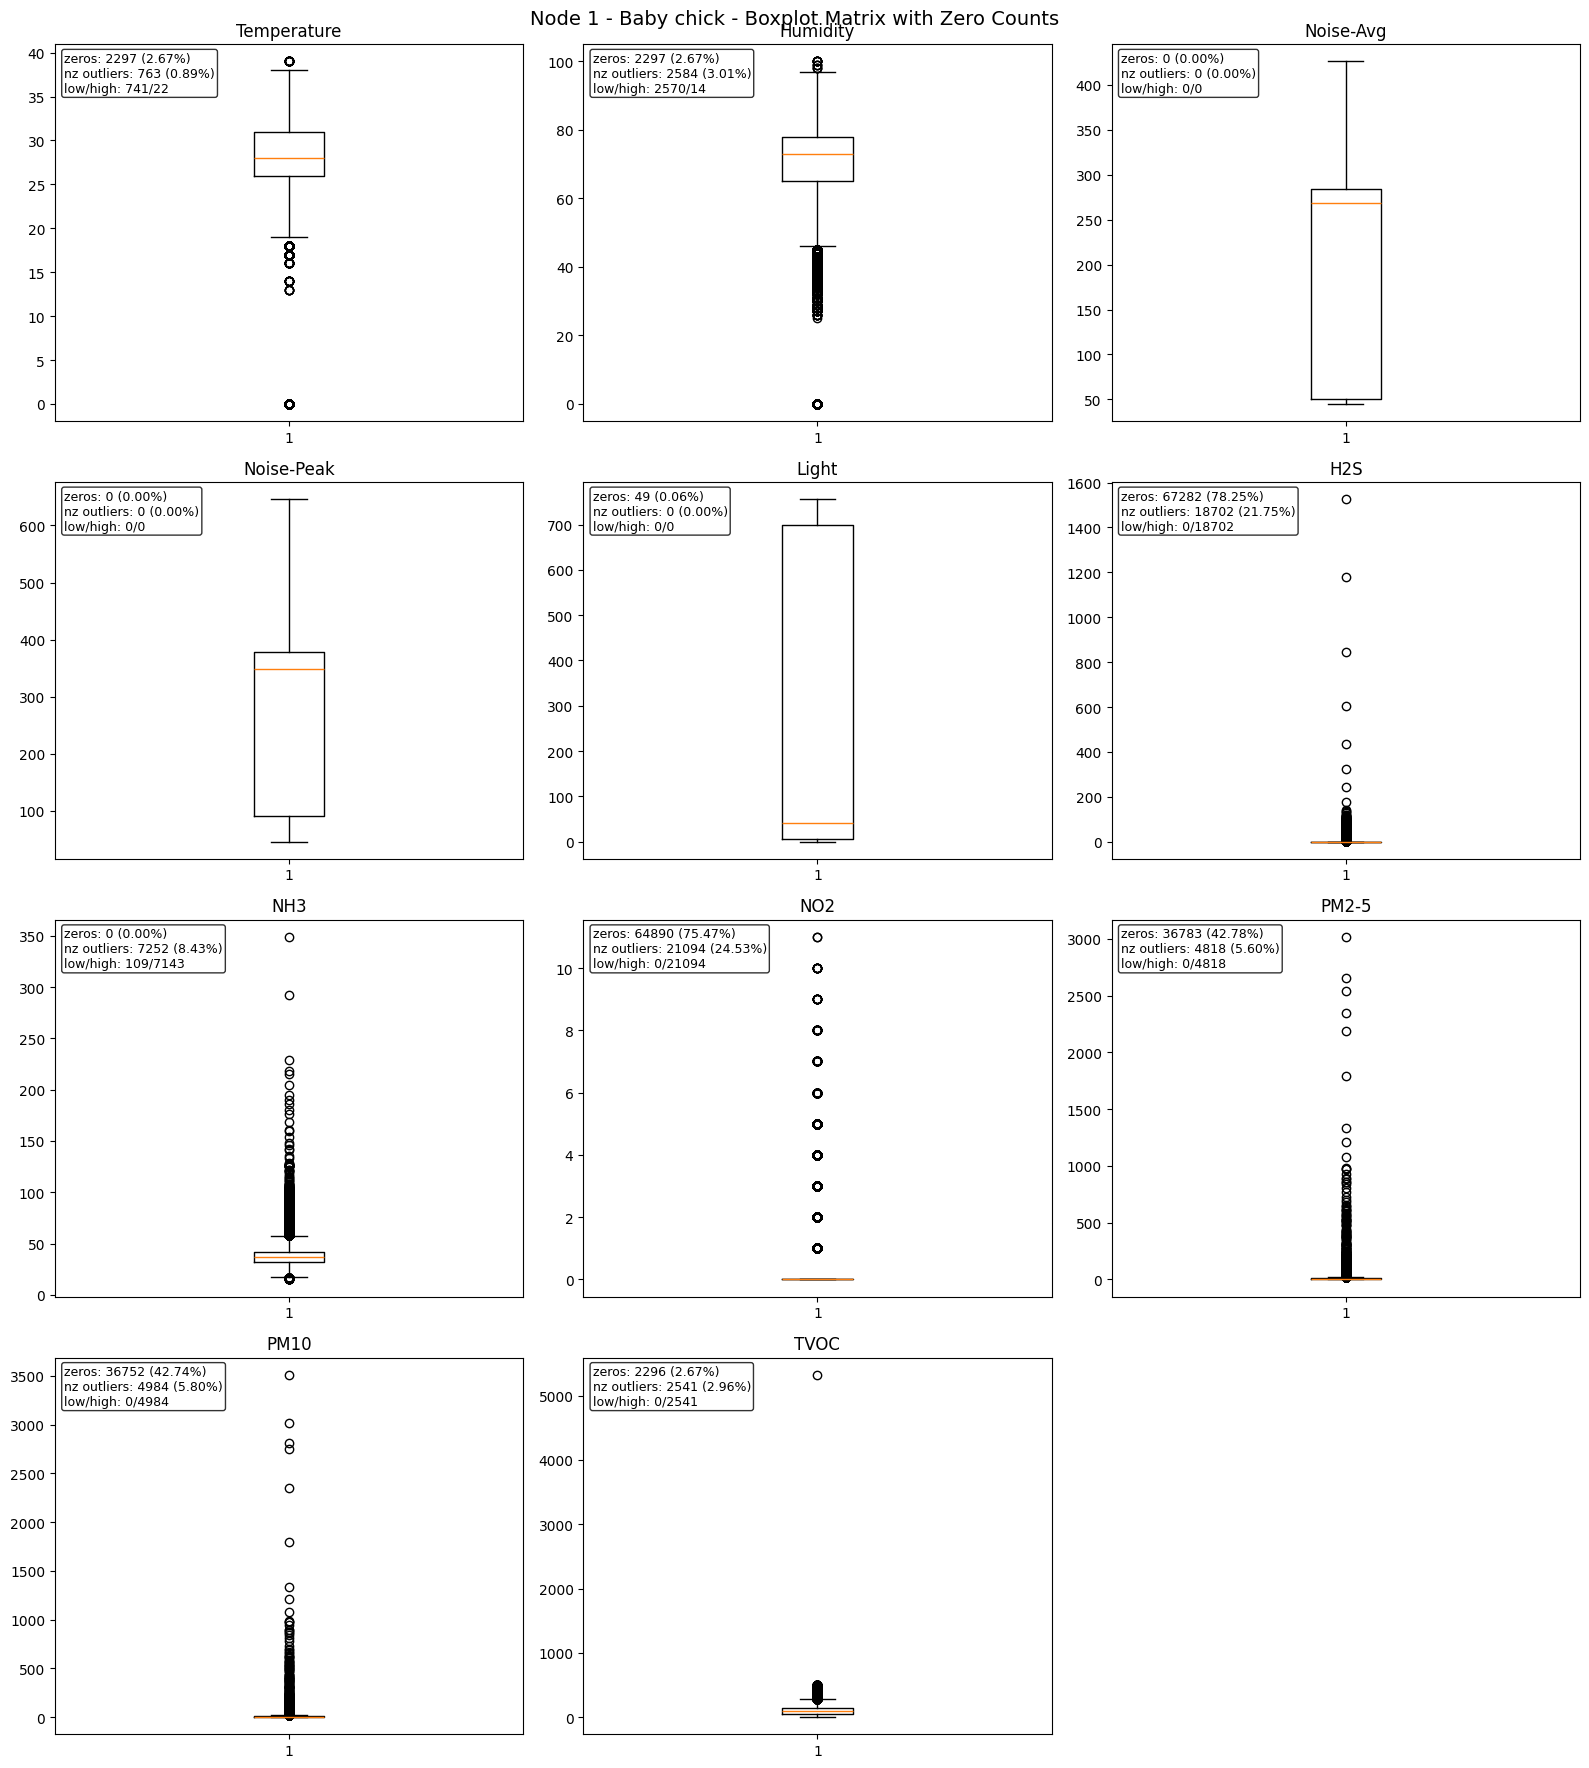

,column,outlier_count,outlier_pct,zero_count,zero_pct,lower_iqr_bound,upper_iqr_bound
7,NO2,21094,24.53,64890,75.47,0.0,0.0
5,H2S,18702,21.75,67282,78.25,0.0,0.0
6,NH3,7252,8.43,0,0.00,17.0,57.0
9,PM10,4984,5.80,36752,42.74,-13.5,22.5
1,Humidity,4881,5.68,2297,2.67,45.5,97.5
8,PM2-5,4818,5.60,36783,42.78,-13.5,22.5
0,Temperature,3060,3.56,2297,2.67,18.5,38.5
10,TVOC,2541,2.96,2296,2.67,-83.5,288.5
4,Light,0,0.00,49,0.06,-1032.0,1736.0
2,Noise-Avg,0,0.00,0,0.00,-298.5,633.5



=== Node 2 - Main East ===


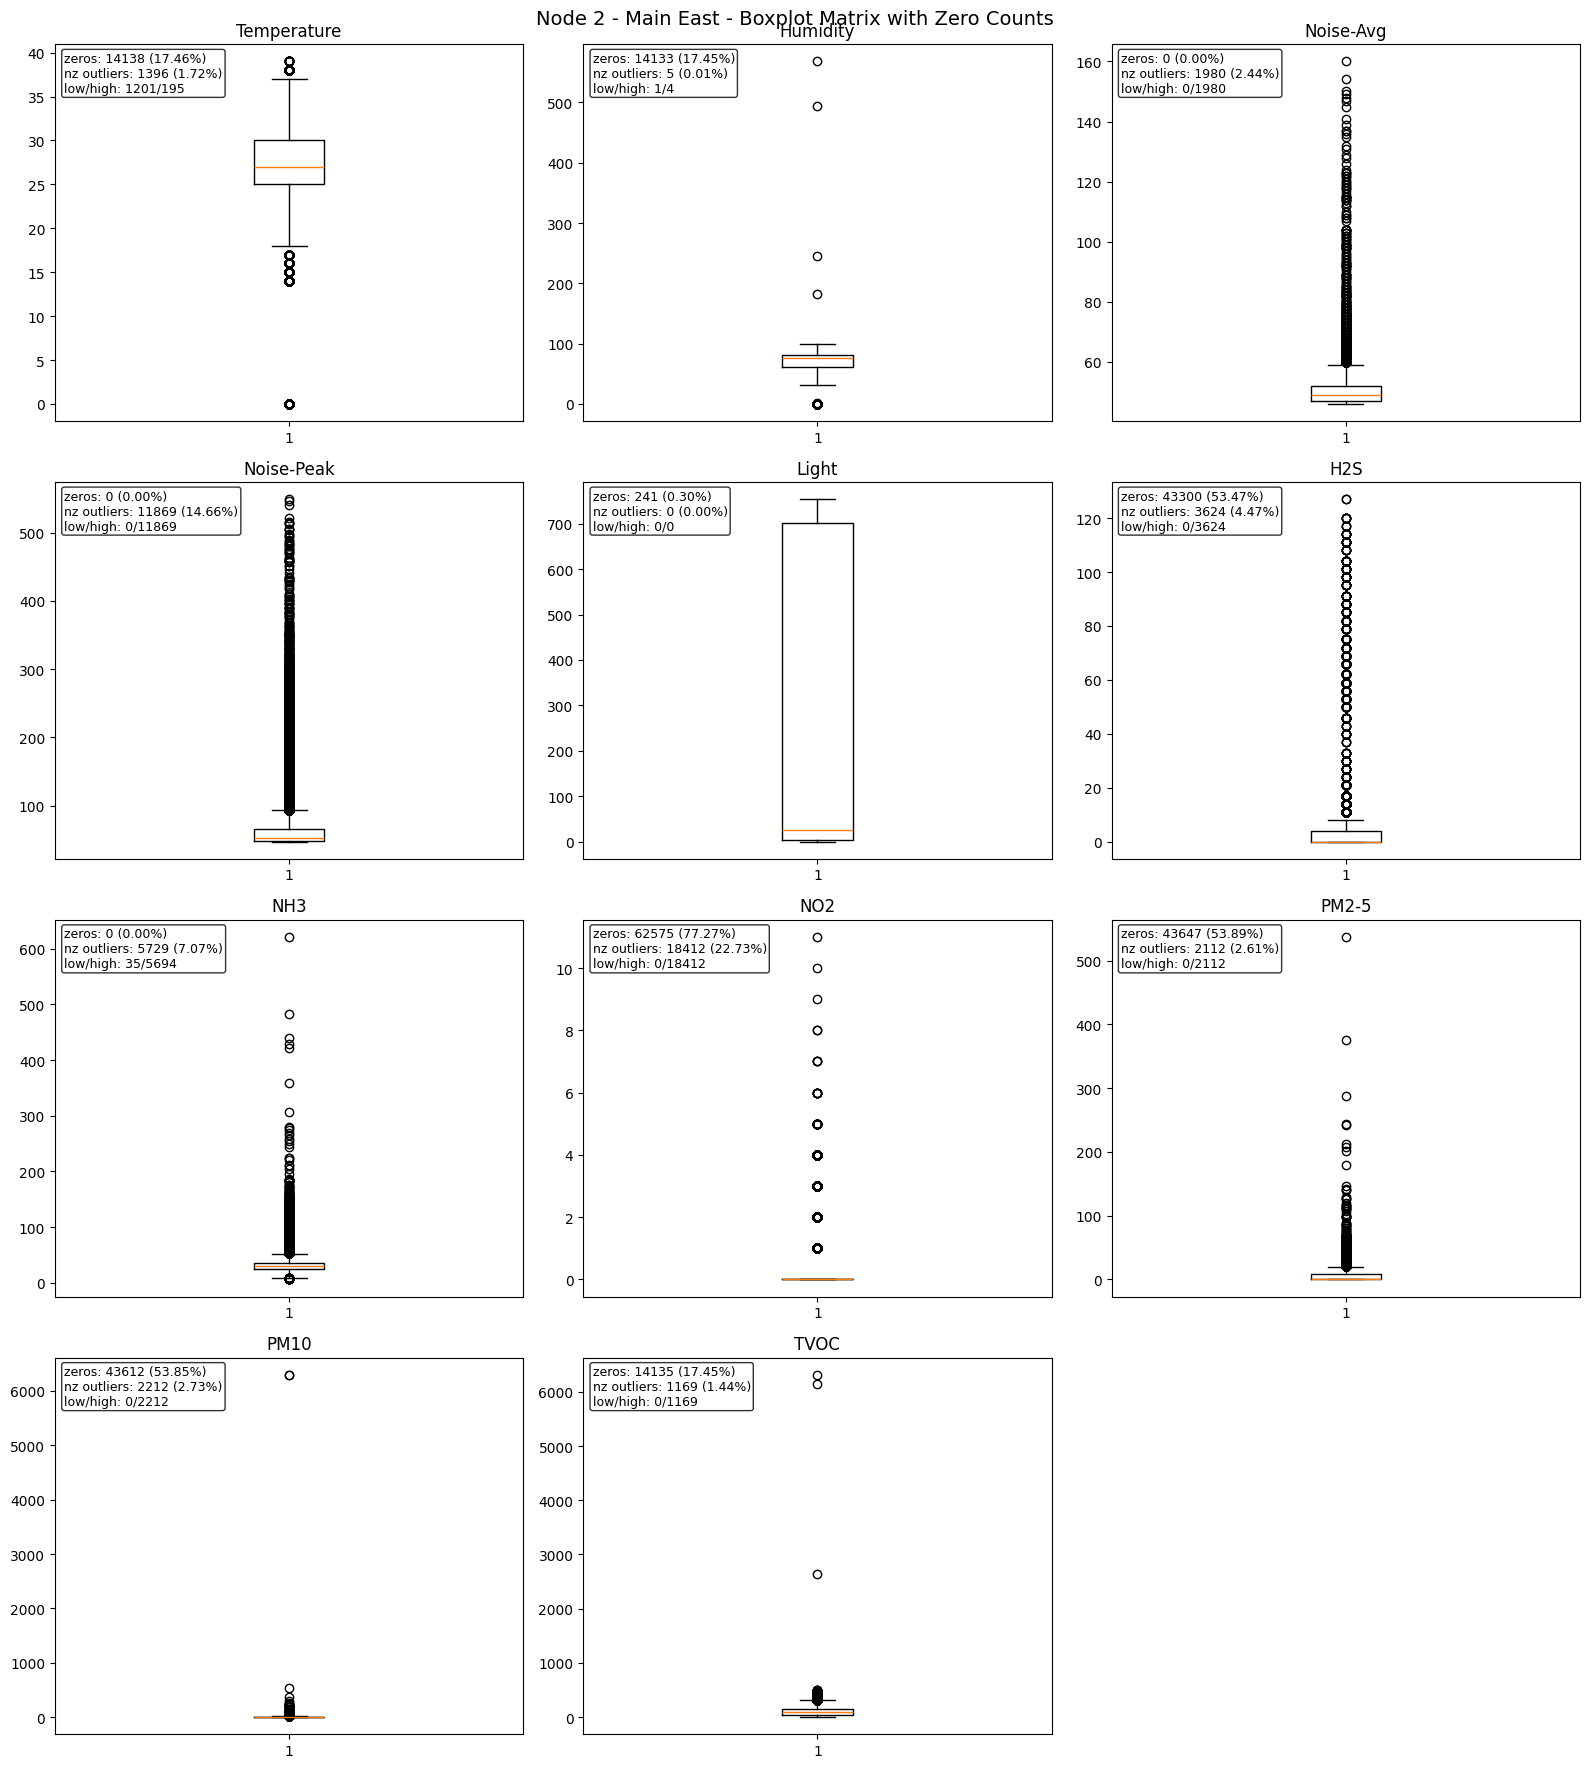

,column,outlier_count,outlier_pct,zero_count,zero_pct,lower_iqr_bound,upper_iqr_bound
7,NO2,18412,22.73,62575,77.27,0.0,0.0
0,Temperature,15534,19.18,14138,17.46,17.5,37.5
1,Humidity,14138,17.46,14133,17.45,31.0,111.0
3,Noise-Peak,11869,14.66,0,0.00,21.0,93.0
6,NH3,5729,7.07,0,0.00,8.5,52.5
5,H2S,3624,4.47,43300,53.47,-6.0,10.0
9,PM10,2212,2.73,43612,53.85,-12.0,20.0
8,PM2-5,2112,2.61,43647,53.89,-12.0,20.0
2,Noise-Avg,1980,2.44,0,0.00,39.5,59.5
10,TVOC,1169,1.44,14135,17.45,-120.5,315.5



=== Node 3 - Main West ===


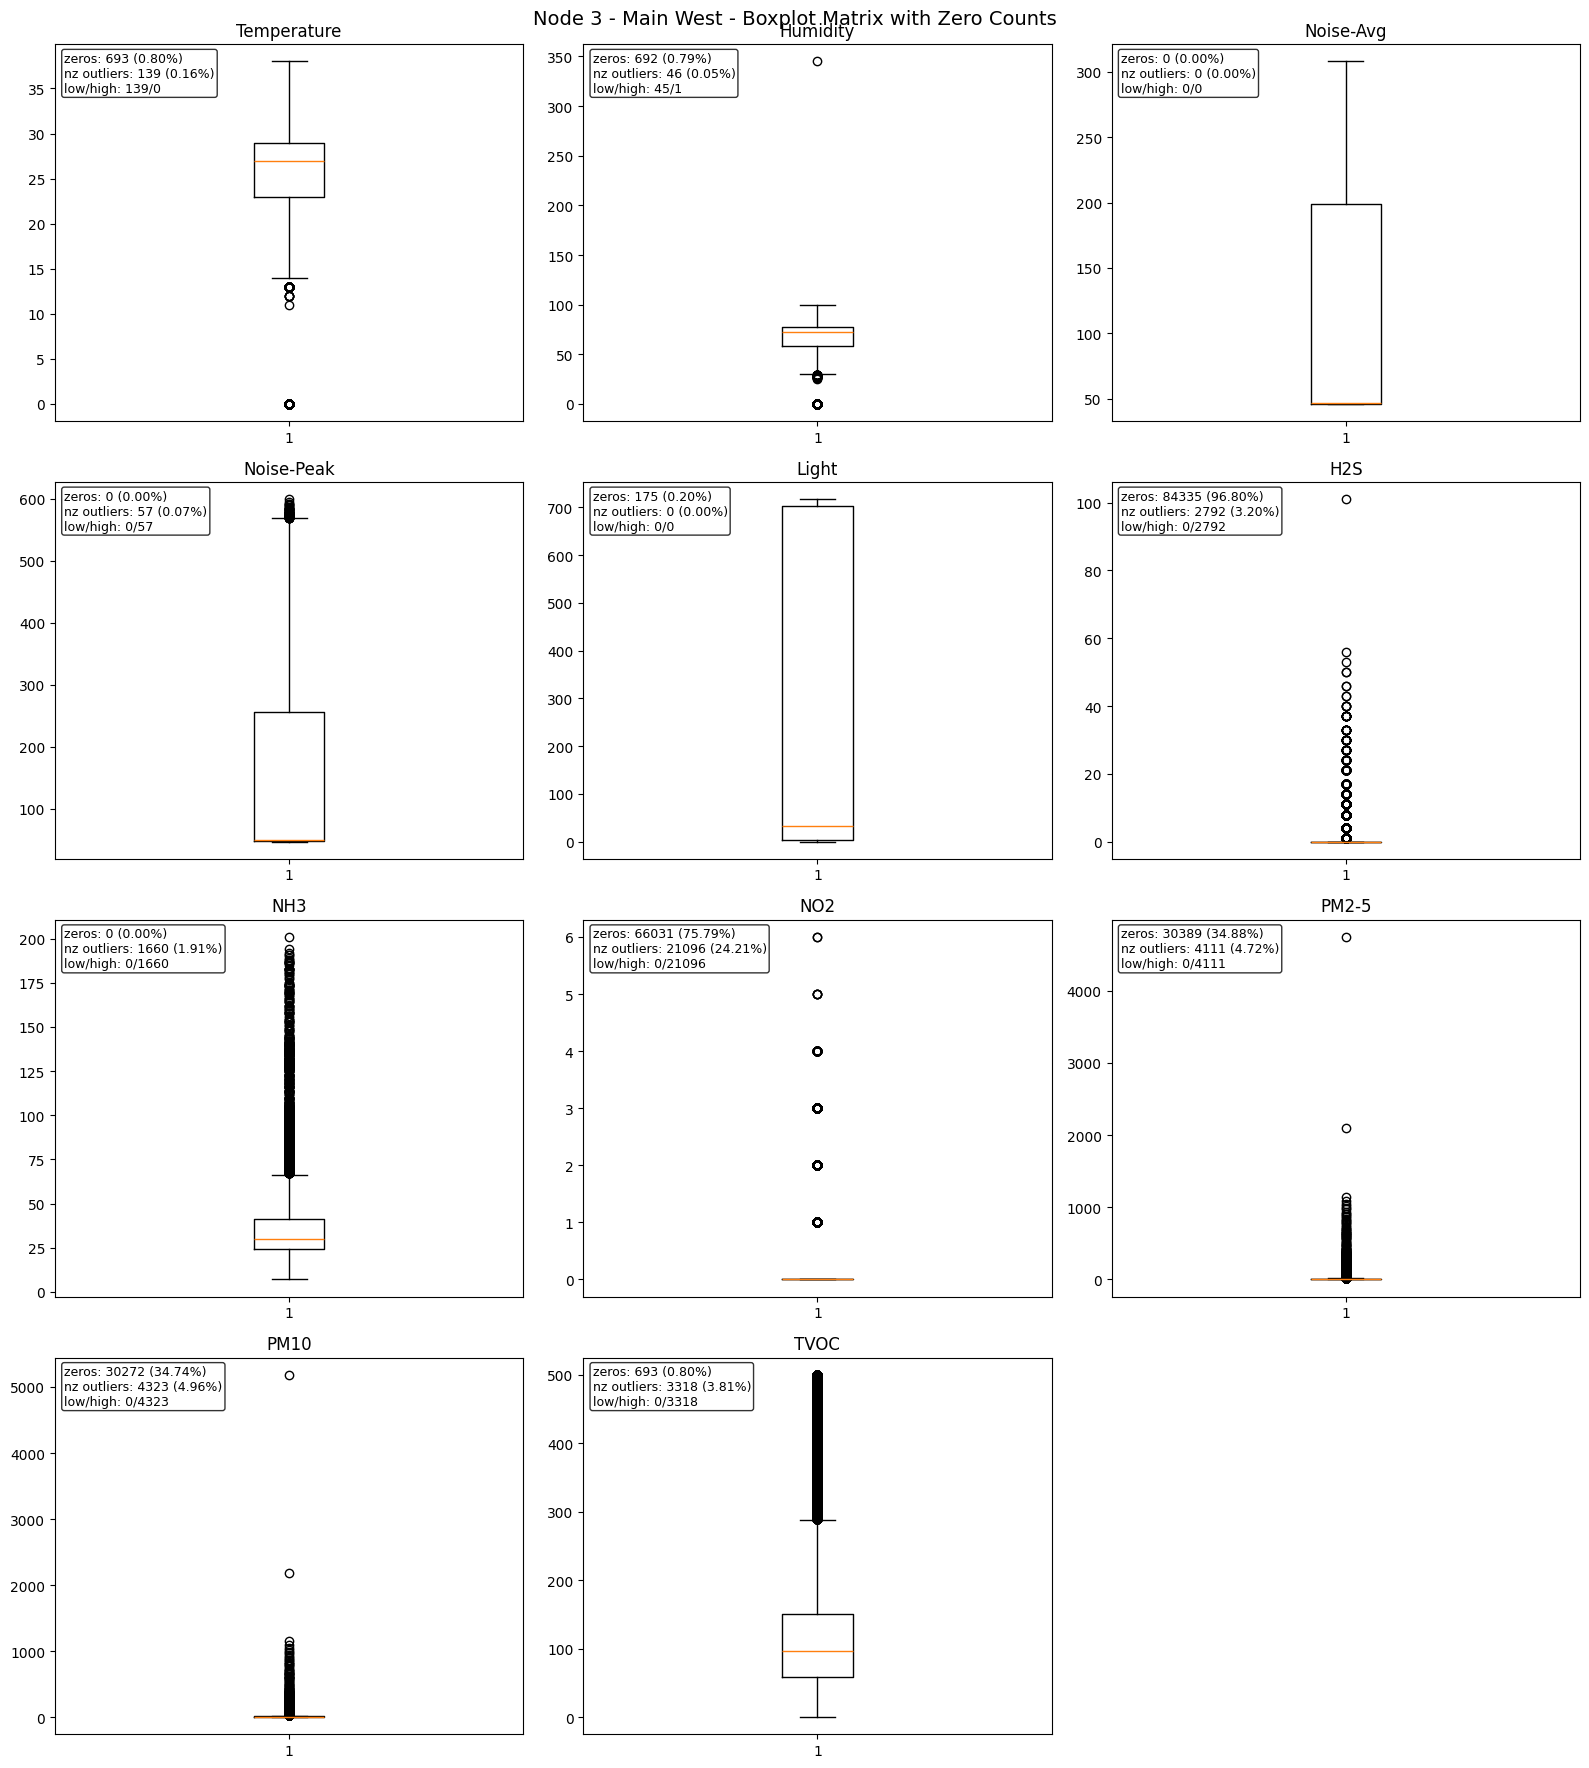

,column,outlier_count,outlier_pct,zero_count,zero_pct,lower_iqr_bound,upper_iqr_bound
7,NO2,21096,24.21,66031,75.79,0.0,0.0
9,PM10,4323,4.96,30272,34.74,-15.0,25.0
8,PM2-5,4111,4.72,30389,34.88,-15.0,25.0
10,TVOC,3318,3.81,693,0.80,-80.0,288.0
5,H2S,2792,3.20,84335,96.80,0.0,0.0
6,NH3,1660,1.91,0,0.00,-1.5,66.5
0,Temperature,832,0.95,693,0.80,14.0,38.0
1,Humidity,738,0.85,692,0.79,29.5,105.5
3,Noise-Peak,57,0.07,0,0.00,-264.0,568.0
4,Light,0,0.00,175,0.20,-1043.0,1749.0


In [50]:
# 3) Outlier check per numeric column + zero-value review
# We will decide later which zeros are invalid and convert those to NaN.
import matplotlib.pyplot as plt


def iqr_outlier_mask(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (series < lower) | (series > upper), lower, upper


for name, df in datasets.items():
    numeric_cols = df.select_dtypes(include=[np.number]).columns

    rows = []
    for col in numeric_cols:
        s = df[col].dropna()
        if s.empty:
            rows.append({
                "column": col,
                "outlier_count": 0,
                "outlier_pct": 0.0,
                "zero_count": 0,
                "zero_pct": 0.0,
                "lower_iqr_bound": np.nan,
                "upper_iqr_bound": np.nan,
            })
            continue

        outlier_mask, lower, upper = iqr_outlier_mask(s)
        outlier_count = int(outlier_mask.sum())
        zero_count = int((s == 0).sum())

        rows.append({
            "column": col,
            "outlier_count": outlier_count,
            "outlier_pct": round((outlier_count / len(s)) * 100, 2),
            "zero_count": zero_count,
            "zero_pct": round((zero_count / len(s)) * 100, 2),
            "lower_iqr_bound": round(lower, 3),
            "upper_iqr_bound": round(upper, 3),
        })

    outlier_report = pd.DataFrame(rows).sort_values(["outlier_count", "zero_count"], ascending=False)

    print(f"=== {name} ===")

    # Boxplot matrix (before tabular outlier report)
    n_cols = len(numeric_cols)
    n_plot_cols = 3
    n_plot_rows = int(np.ceil(n_cols / n_plot_cols))

    fig, axes = plt.subplots(n_plot_rows, n_plot_cols, figsize=(16, 4.5 * n_plot_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(numeric_cols):
        ax = axes[i]
        s = df[col].dropna()
        if s.empty:
            ax.set_title(f"{col}\n(no valid values)")
            ax.axis("off")
            continue

        ax.boxplot(s.values, vert=True)
        zero_count = int((s == 0).sum())
        zero_pct = (zero_count / len(s)) * 100

        outlier_mask, lower, upper = iqr_outlier_mask(s)
        non_zero_outlier_mask = outlier_mask & (s != 0)
        low_non_zero_outliers = int(((s < lower) & (s != 0)).sum())
        high_non_zero_outliers = int(((s > upper) & (s != 0)).sum())
        non_zero_outlier_count = int(non_zero_outlier_mask.sum())
        non_zero_outlier_pct = (non_zero_outlier_count / len(s)) * 100

        ax.set_title(col)
        ax.text(
            0.02,
            0.98,
            (
                f"zeros: {zero_count} ({zero_pct:.2f}%)\n"
                f"nz outliers: {non_zero_outlier_count} ({non_zero_outlier_pct:.2f}%)\n"
                f"low/high: {low_non_zero_outliers}/{high_non_zero_outliers}"
            ),
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8),
        )

    # Hide any unused subplot axes
    for j in range(n_cols, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"{name} - Boxplot Matrix with Zero Counts", fontsize=14)
    plt.tight_layout()
    plt.show()

    display(outlier_report)
    print()

At this stage, we will remove extreme outliers as that look like clear misinput/invalid entries. As for other anomolies and patterns, this can be detected later on.


| Column | Node 1 | Node 2 | Node 3 |
|------|-----|------------|------|
| NO2 | x | x | x |
| PM10 | x | x | x |
| PM2-5 | x | x | x |
| TVOC | x | x | x |
| H2S | x | x | x |
| NH3 | x | x | x |
| Temperature |Zeros (2.5%) seem to be outliers | Zeros (17.46%) seem to be outliers | Zeros (0.8%) seem to be outliers |
| Humidty |Zeros (2.5%) seem to be outliers | Zeros (17.46%) seem to be outliers | Zeros (0.8%) seem to be outliers |Zeros () seem to be outliers |
| Noise-Peak | x | x | x |
| Light | x | x | x |
| Noise-Avg | x | x | x |

In [51]:
zero_as_missing_cols = ["Temperature", "Humidity"]

for name, df in datasets.items():
    for col in zero_as_missing_cols:
        if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
            df.loc[df[col] == 0, col] = np.nan

print("Applied zero->NaN conversion for columns:", zero_as_missing_cols)
print("(Leave list empty until you finalize zero-misinput decisions.)")

Applied zero->NaN conversion for columns: ['Temperature', 'Humidity']
(Leave list empty until you finalize zero-misinput decisions.)


In [52]:
# 5b) Partial missingness with explicit missing columns and percentages
# Use this in place of the previous partial-missing breakdown.
for name, df in datasets.items():
    missing_counts = df.isna().sum(axis=1)
    partial_mask = (missing_counts >= 1) & (missing_counts < df.shape[1])
    partial_df = df.loc[partial_mask]

    total_rows = len(df)
    partial_rows = len(partial_df)

    print(f"=== {name} ===")
    print(f"Rows with partial missing values: {partial_rows} / {total_rows} ({(partial_rows / total_rows) * 100:.2f}%)")

    if partial_rows == 0:
        print("No partially-missing rows.")
    else:
        pattern_series = partial_df.isna().apply(
            lambda r: tuple(col for col, is_missing in r.items() if is_missing),
            axis=1,
        )

        pattern_breakdown = pattern_series.value_counts().rename_axis("missing_columns").reset_index(name="row_count")
        pattern_breakdown["missing_columns"] = pattern_breakdown["missing_columns"].apply(lambda cols: ", ".join(cols))
        pattern_breakdown["missing_values_in_pattern"] = pattern_breakdown["missing_columns"].str.count(",") + 1
        pattern_breakdown["pct_of_total_rows"] = (pattern_breakdown["row_count"] / total_rows * 100).round(2)
        pattern_breakdown["pct_of_partial_rows"] = (pattern_breakdown["row_count"] / partial_rows * 100).round(2)

        display(
            pattern_breakdown[
                [
                    "missing_columns",
                    "missing_values_in_pattern",
                    "row_count",
                    "pct_of_total_rows",
                    "pct_of_partial_rows",
                ]
            ]
        )

    print()

=== Node 1 - Baby chick ===
Rows with partial missing values: 2297 / 85984 (2.67%)


,missing_columns,missing_values_in_pattern,row_count,pct_of_total_rows,pct_of_partial_rows
0,"Temperature, Humidity",2,2297,2.67,100.0



=== Node 2 - Main East ===
Rows with partial missing values: 14138 / 80987 (17.46%)


,missing_columns,missing_values_in_pattern,row_count,pct_of_total_rows,pct_of_partial_rows
0,"Temperature, Humidity",2,14133,17.45,99.96
1,Temperature,1,5,0.01,0.04



=== Node 3 - Main West ===
Rows with partial missing values: 693 / 87127 (0.80%)


,missing_columns,missing_values_in_pattern,row_count,pct_of_total_rows,pct_of_partial_rows
0,"Temperature, Humidity",2,692,0.79,99.86
1,Temperature,1,1,0.00,0.14


### 6- Add dataset-specific IDs at the start of each dataframe
Example IDs: node01-00001, node02-00001, node03-00001

In [53]:


id_prefix_map = {
    "Node 1 - Baby chick": "node01",
    "Node 2 - Main East": "node02",
    "Node 3 - Main West": "node03",
}

for name, df in datasets.items():
    prefix = id_prefix_map.get(name, "nodeXX")

    # Keep current order; assign sequential IDs from 1
    generated_ids = [f"{prefix}-{i:05d}" for i in range(1, len(df) + 1)]

    # Insert at first position (or overwrite if already present)
    if "row_id" in df.columns:
        df["row_id"] = generated_ids
        cols = ["row_id"] + [c for c in df.columns if c != "row_id"]
        datasets[name] = df[cols]
    else:
        df.insert(0, "row_id", generated_ids)

    print(f"{name}: row_id added, sample -> {df['row_id'].iloc[0]} ... {df['row_id'].iloc[-1]}")

Node 1 - Baby chick: row_id added, sample -> node01-00001 ... node01-85984
Node 2 - Main East: row_id added, sample -> node02-00001 ... node02-80987
Node 3 - Main West: row_id added, sample -> node03-00001 ... node03-87127


In [54]:
# 4) Check how many fully-missing rows each dataset has
for name, df in datasets.items():
    fully_missing_mask = df.isna().all(axis=1)
    full_missing_rows = int(fully_missing_mask.sum())
    print(f"{name}: full rows missing = {full_missing_rows} / {len(df)} ({(full_missing_rows/len(df))*100:.2f}%)")

Node 1 - Baby chick: full rows missing = 0 / 85984 (0.00%)
Node 2 - Main East: full rows missing = 0 / 80987 (0.00%)
Node 3 - Main West: full rows missing = 0 / 87127 (0.00%)


In [55]:
# 5) Check how many rows are missing 1 to a few values (partial missingness)
for name, df in datasets.items():
    missing_per_row = df.isna().sum(axis=1)

    partial_missing = missing_per_row[(missing_per_row >= 1) & (missing_per_row < df.shape[1])]
    distribution = partial_missing.value_counts().sort_index()

    print(f"=== {name} ===")
    print(f"Rows with partial missing values: {len(partial_missing)} / {len(df)} ({(len(partial_missing)/len(df))*100:.2f}%)")

    if distribution.empty:
        print("No partially-missing rows.")
    else:
        print("Breakdown by number of missing values in a row:")
        display(distribution.rename("row_count").to_frame())
    print()

=== Node 1 - Baby chick ===
Rows with partial missing values: 2297 / 85984 (2.67%)
Breakdown by number of missing values in a row:


,row_count
2,2297



=== Node 2 - Main East ===
Rows with partial missing values: 14138 / 80987 (17.46%)
Breakdown by number of missing values in a row:


,row_count
1,5
2,14133



=== Node 3 - Main West ===
Rows with partial missing values: 693 / 87127 (0.80%)
Breakdown by number of missing values in a row:


,row_count
1,1
2,692


In [56]:
# 9) Noise-unit diagnostic: raw vs divided-by-10 interpretation
# This helps decide whether Noise-Avg/Noise-Peak are true dB or scaled values.

noise_cols = ["Noise-Avg", "Noise-Peak"]


def summarize_noise(series):
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        return {"count": 0, "median": np.nan, "q1": np.nan, "q3": np.nan, "iqr": np.nan, "p95": np.nan, "max": np.nan}

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    return {
        "count": int(len(s)),
        "median": round(float(s.median()), 2),
        "q1": round(float(q1), 2),
        "q3": round(float(q3), 2),
        "iqr": round(float(q3 - q1), 2),
        "p95": round(float(s.quantile(0.95)), 2),
        "max": round(float(s.max()), 2),
    }


def plausibility_tag(median_val, max_val):
    # Heuristic only (not a hard rule): poultry-house ambient averages are rarely ultra-quiet.
    if pd.isna(median_val):
        return "no_data"
    if median_val < 30:
        return "too_low_for_barn"
    if max_val > 190:
        return "too_high_for_physical_dB"
    return "plausible_range"


rows = []
for ds_name, df in datasets.items():
    for col in noise_cols:
        if col not in df.columns:
            continue

        raw_stats = summarize_noise(df[col])
        div10_stats = summarize_noise(pd.to_numeric(df[col], errors="coerce") / 10.0)

        rows.append({
            "dataset": ds_name,
            "column": col,
            "interpretation": "raw",
            **raw_stats,
            "plausibility": plausibility_tag(raw_stats["median"], raw_stats["max"]),
        })
        rows.append({
            "dataset": ds_name,
            "column": col,
            "interpretation": "div_by_10",
            **div10_stats,
            "plausibility": plausibility_tag(div10_stats["median"], div10_stats["max"]),
        })

noise_diag = pd.DataFrame(rows)

print("Noise interpretation diagnostic (heuristic):")
display(noise_diag.sort_values(["dataset", "column", "interpretation"]))

print("\nQuick comparison by dataset/column:")
for ds_name in noise_diag["dataset"].unique():
    print(f"=== {ds_name} ===")
    for col in noise_cols:
        subset = noise_diag[(noise_diag["dataset"] == ds_name) & (noise_diag["column"] == col)]
        if subset.empty:
            continue
        raw_row = subset[subset["interpretation"] == "raw"].iloc[0]
        div_row = subset[subset["interpretation"] == "div_by_10"].iloc[0]
        print(
            f"{col}: raw median/max={raw_row['median']}/{raw_row['max']} ({raw_row['plausibility']}), "
            f"div10 median/max={div_row['median']}/{div_row['max']} ({div_row['plausibility']})"
        )
    print()

Noise interpretation diagnostic (heuristic):


,dataset,column,interpretation,count,median,q1,q3,iqr,p95,max,plausibility
1,Node 1 - Baby chick,Noise-Avg,div_by_10,85984,26.9,5.1,28.4,23.3,35.6,42.6,too_low_for_barn
0,Node 1 - Baby chick,Noise-Avg,raw,85984,269.0,51.0,284.0,233.0,356.0,426.0,too_high_for_physical_dB
3,Node 1 - Baby chick,Noise-Peak,div_by_10,85984,34.8,9.1,37.9,28.8,42.5,64.6,plausible_range
2,Node 1 - Baby chick,Noise-Peak,raw,85984,348.0,91.0,379.0,288.0,425.0,646.0,too_high_for_physical_dB
5,Node 2 - Main East,Noise-Avg,div_by_10,80987,4.9,4.7,5.2,0.5,5.7,16.0,too_low_for_barn
4,Node 2 - Main East,Noise-Avg,raw,80987,49.0,47.0,52.0,5.0,57.0,160.0,plausible_range
7,Node 2 - Main East,Noise-Peak,div_by_10,80987,5.2,4.8,6.6,1.8,15.3,54.9,too_low_for_barn
6,Node 2 - Main East,Noise-Peak,raw,80987,52.0,48.0,66.0,18.0,153.0,549.0,too_high_for_physical_dB
9,Node 3 - Main West,Noise-Avg,div_by_10,87127,4.7,4.6,19.9,15.3,26.0,30.8,too_low_for_barn
8,Node 3 - Main West,Noise-Avg,raw,87127,47.0,46.0,199.0,153.0,260.0,308.0,too_high_for_physical_dB



Quick comparison by dataset/column:
=== Node 1 - Baby chick ===
Noise-Avg: raw median/max=269.0/426.0 (too_high_for_physical_dB), div10 median/max=26.9/42.6 (too_low_for_barn)
Noise-Peak: raw median/max=348.0/646.0 (too_high_for_physical_dB), div10 median/max=34.8/64.6 (plausible_range)

=== Node 2 - Main East ===
Noise-Avg: raw median/max=49.0/160.0 (plausible_range), div10 median/max=4.9/16.0 (too_low_for_barn)
Noise-Peak: raw median/max=52.0/549.0 (too_high_for_physical_dB), div10 median/max=5.2/54.9 (too_low_for_barn)

=== Node 3 - Main West ===
Noise-Avg: raw median/max=47.0/308.0 (too_high_for_physical_dB), div10 median/max=4.7/30.8 (too_low_for_barn)
Noise-Peak: raw median/max=50.0/599.0 (too_high_for_physical_dB), div10 median/max=5.0/59.9 (too_low_for_barn)



In [60]:
# 10) Find datetimes with "crazy" noise values
# You can adjust thresholds if needed.

crazy_thresholds = {
    "Noise-Avg": 140,
    "Noise-Peak": 140,
}

for name, df in datasets.items():
    print(f"=== {name} ===")

    available_noise_cols = [c for c in crazy_thresholds.keys() if c in df.columns]
    if not available_noise_cols:
        print("No noise columns found.")
        print()
        continue

    # Build mask for any crazy value across configured noise columns
    crazy_mask = pd.Series(False, index=df.index)
    for col in available_noise_cols:
        s = pd.to_numeric(df[col], errors="coerce")
        crazy_mask = crazy_mask | (s > crazy_thresholds[col]) | (s < 0)

    crazy_rows = df.loc[crazy_mask].copy()

    if crazy_rows.empty:
        print("No crazy noise values found with current thresholds.")
        print()
        continue

    # Keep key columns first
    lead_cols = [c for c in ["row_id", "Time", "Noise-Avg", "Noise-Peak"] if c in crazy_rows.columns]
    extra_cols = [c for c in crazy_rows.columns if c not in lead_cols]
    crazy_rows = crazy_rows[lead_cols + extra_cols]

    # Add reason text for easier auditing
    reasons = []
    for _, row in crazy_rows.iterrows():
        r = []
        for col in available_noise_cols:
            val = pd.to_numeric(row[col], errors="coerce")
            if pd.notna(val):
                if val > crazy_thresholds[col]:
                    r.append(f"{col}>{crazy_thresholds[col]} ({val})")
                elif val < 0:
                    r.append(f"{col}<0 ({val})")
        reasons.append("; ".join(r))

    crazy_rows.insert(len(lead_cols), "crazy_reason", reasons)

    print(f"Rows with crazy noise values: {len(crazy_rows)}")
    display(crazy_rows[[c for c in ["row_id", "Time", "Noise-Avg", "Noise-Peak", "crazy_reason"] if c in crazy_rows.columns]])
    print()

=== Node 1 - Baby chick ===
Rows with crazy noise values: 55310


,row_id,Time,Noise-Avg,Noise-Peak,crazy_reason
5,node01-00006,02/02/2024 9:25,50,381,Noise-Peak>140 (381)
17,node01-00018,02/02/2024 10:25,59,415,Noise-Peak>140 (415)
18,node01-00019,02/02/2024 10:39,50,303,Noise-Peak>140 (303)
22,node01-00023,02/02/2024 10:59,48,323,Noise-Peak>140 (323)
26,node01-00027,02/02/2024 11:19,48,316,Noise-Peak>140 (316)
...,...,...,...,...,...
83682,node01-85980,04/07/2025 13:44,301,548,Noise-Avg>140 (301); Noise-Peak>140 (548)
83683,node01-85981,04/07/2025 13:59,295,578,Noise-Avg>140 (295); Noise-Peak>140 (578)
83684,node01-85982,04/07/2025 14:05,298,481,Noise-Avg>140 (298); Noise-Peak>140 (481)
83685,node01-85983,04/07/2025 14:12,297,444,Noise-Avg>140 (297); Noise-Peak>140 (444)



=== Node 2 - Main East ===
Rows with crazy noise values: 4445


,row_id,Time,Noise-Avg,Noise-Peak,crazy_reason
0,node02-00001,01/02/2024 21:31,53,498,Noise-Peak>140 (498)
4,node02-00005,02/02/2024 10:58,55,350,Noise-Peak>140 (350)
8,node02-00009,02/02/2024 11:24,53,384,Noise-Peak>140 (384)
31,node02-00032,02/02/2024 13:24,59,457,Noise-Peak>140 (457)
44,node02-00045,02/02/2024 14:29,53,457,Noise-Peak>140 (457)
...,...,...,...,...,...
66837,node02-80976,04/07/2025 13:43,50,189,Noise-Peak>140 (189)
66838,node02-80977,04/07/2025 13:48,52,240,Noise-Peak>140 (240)
66843,node02-80982,04/07/2025 14:13,50,204,Noise-Peak>140 (204)
66845,node02-80984,04/07/2025 14:23,49,144,Noise-Peak>140 (144)



=== Node 3 - Main West ===
Rows with crazy noise values: 35698


,row_id,Time,Noise-Avg,Noise-Peak,crazy_reason
0,node03-00001,07/02/2024 13:55,211,494,Noise-Avg>140 (211); Noise-Peak>140 (494)
1,node03-00002,07/02/2024 15:18,211,479,Noise-Avg>140 (211); Noise-Peak>140 (479)
2,node03-00003,07/02/2024 15:26,210,473,Noise-Avg>140 (210); Noise-Peak>140 (473)
3,node03-00004,07/02/2024 15:51,231,493,Noise-Avg>140 (231); Noise-Peak>140 (493)
4,node03-00005,07/02/2024 15:56,236,482,Noise-Avg>140 (236); Noise-Peak>140 (482)
...,...,...,...,...,...
86426,node03-87120,04/07/2025 12:40,50,354,Noise-Peak>140 (354)
86429,node03-87123,04/07/2025 13:03,49,473,Noise-Peak>140 (473)
86431,node03-87125,04/07/2025 13:32,48,336,Noise-Peak>140 (336)
86432,node03-87126,04/07/2025 13:55,48,278,Noise-Peak>140 (278)


In [57]:
# 8) Show clearly which extreme high outliers were removed
# Focuses on "random huge" spikes (e.g., 5000/6000).

# Rebuild original snapshots (before cleaning edits in datasets)
original_datasets = {
    "Node 1 - Baby chick": df_1.copy(),
    "Node 2 - Main East": df_2.copy(),
    "Node 3 - Main West": df_3.copy(),
}

# Ensure same row_id logic exists on originals for exact matching
id_prefix_map = {
    "Node 1 - Baby chick": "node01",
    "Node 2 - Main East": "node02",
    "Node 3 - Main West": "node03",
}

for name, odf in original_datasets.items():
    odf.columns = [c.strip() for c in odf.columns]
    prefix = id_prefix_map[name]
    odf.insert(0, "row_id", [f"{prefix}-{i:05d}" for i in range(1, len(odf) + 1)])
    original_datasets[name] = odf

# Set this threshold to control how "extreme" should be defined
EXTREME_MIN_VALUE = 1000

for name in original_datasets.keys():
    original_df = original_datasets[name]
    cleaned_df = datasets[name]

    numeric_cols = [c for c in original_df.columns if c in cleaned_df.columns and c not in ["row_id", "Time"]]

    # Wide -> long for easier filtering/reporting
    orig_long = original_df[["row_id", "Time"] + numeric_cols].melt(
        id_vars=["row_id", "Time"],
        var_name="column",
        value_name="original_value",
    )

    # keep only numeric + extreme high values
    orig_long["original_value"] = pd.to_numeric(orig_long["original_value"], errors="coerce")
    extreme = orig_long[orig_long["original_value"] >= EXTREME_MIN_VALUE].copy()

    # check if the same row_id still exists after cleaning
    cleaned_ids = set(cleaned_df["row_id"].astype(str)) if "row_id" in cleaned_df.columns else set()
    extreme["row_kept_after_cleaning"] = extreme["row_id"].astype(str).isin(cleaned_ids)
    extreme["status"] = np.where(extreme["row_kept_after_cleaning"], "KEPT", "REMOVED")

    # sort for readability (largest first)
    extreme = extreme.sort_values(["status", "original_value"], ascending=[True, False])

    print(f"=== {name} ===")
    print(f"Extreme threshold: value >= {EXTREME_MIN_VALUE}")

    if extreme.empty:
        print("No extreme high values found with current threshold.")
    else:
        summary = extreme["status"].value_counts().rename_axis("status").reset_index(name="count")
        display(summary)
        display(extreme[["row_id", "Time", "column", "original_value", "status"]])

    print()

=== Node 1 - Baby chick ===
Extreme threshold: value >= 1000


,status,count
0,KEPT,21


,row_id,Time,column,original_value,status
927198,node01-67359,16/02/2025 17:57,TVOC,5325,KEPT
788611,node01-14756,22/05/2024 2:03,PM10,3511,KEPT
718124,node01-30253,09/08/2024 5:18,PM2-5,3016,KEPT
804108,node01-30253,09/08/2024 5:18,PM10,3016,KEPT
788610,node01-14755,22/05/2024 1:58,PM10,2813,KEPT
777486,node01-03631,09/04/2024 5:43,PM10,2749,KEPT
691502,node01-03631,09/04/2024 5:43,PM2-5,2657,KEPT
702627,node01-14756,22/05/2024 2:03,PM2-5,2543,KEPT
718123,node01-30252,09/08/2024 5:13,PM2-5,2345,KEPT
804107,node01-30252,09/08/2024 5:13,PM10,2345,KEPT



=== Node 2 - Main East ===
Extreme threshold: value >= 1000


,status,count
0,KEPT,5


,row_id,Time,column,original_value,status
866785,node02-56916,18/12/2024 12:11,TVOC,6316,KEPT
793098,node02-64216,30/01/2025 0:55,PM10,6297,KEPT
793119,node02-64237,30/01/2025 2:37,PM10,6297,KEPT
866118,node02-56249,15/12/2024 1:48,TVOC,6148,KEPT
873068,node02-63199,26/01/2025 14:39,TVOC,2636,KEPT



=== Node 3 - Main West ===
Extreme threshold: value >= 1000


,status,count
0,KEPT,12


,row_id,Time,column,original_value,status
800704,node03-16562,09/05/2024 14:05,PM10,5186,KEPT
713577,node03-16562,09/05/2024 14:05,PM2-5,4745,KEPT
797622,node03-13480,28/03/2024 18:14,PM10,2184,KEPT
710495,node03-13480,28/03/2024 18:14,PM2-5,2104,KEPT
698208,node03-01193,11/02/2024 19:54,PM2-5,1148,KEPT
785335,node03-01193,11/02/2024 19:54,PM10,1148,KEPT
698209,node03-01194,11/02/2024 19:59,PM2-5,1090,KEPT
785336,node03-01194,11/02/2024 19:59,PM10,1090,KEPT
700403,node03-03388,19/02/2024 21:11,PM2-5,1045,KEPT
787530,node03-03388,19/02/2024 21:11,PM10,1045,KEPT


In [58]:
# 7b) Drop/remove rows with any missing values across all datasets
for name, df in datasets.items():
    before_rows = len(df)
    removed_rows = int(df.isna().any(axis=1).sum())

    # Keep only complete rows
    datasets[name] = df.dropna(axis=0, how="any").reset_index(drop=True)

    after_rows = len(datasets[name])
    print(f"{name}: removed {removed_rows} rows | before={before_rows}, after={after_rows}")
    datasets[name].to_csv(f"{name}_cleaned.csv")

Node 1 - Baby chick: removed 2297 rows | before=85984, after=83687
Node 2 - Main East: removed 14138 rows | before=80987, after=66849
Node 3 - Main West: removed 693 rows | before=87127, after=86434


In [59]:
for df in [df_1, df_2, df_3]:
    print(f"----")
    for col in df.columns:
        print(col, df[col].values.min(), '(min) -', df[col].values.max(), '(max)')

----
Time 01/01/2025 0:04 (min) - 31/12/2024 9:55 (max)
Temperature 0 (min) - 39 (max)
Humidity 0 (min) - 100 (max)
Noise-Avg 45 (min) - 426 (max)
Noise-Peak 46 (min) - 646 (max)
Light 0 (min) - 756 (max)
H2S 0 (min) - 1526 (max)
NH3 15 (min) - 349 (max)
NO2 0 (min) - 11 (max)
PM2-5 0 (min) - 3016 (max)
PM10 0 (min) - 3511 (max)
TVOC 0 (min) - 5325 (max)
----
Time 01/01/2025 0:01 (min) - 31/12/2024 9:58 (max)
Temperature 0 (min) - 39 (max)
Humidity 0 (min) - 568 (max)
Noise-Avg 46 (min) - 160 (max)
Noise-Peak 47 (min) - 549 (max)
Light 0 (min) - 754 (max)
H2S 0 (min) - 127 (max)
NH3 6 (min) - 621 (max)
NO2 0 (min) - 11 (max)
PM2-5 0 (min) - 537 (max)
PM10 0 (min) - 6297 (max)
TVOC 0 (min) - 6316 (max)
----
Time 01/01/2025 0:04 (min) - 31/12/2024 9:55 (max)
Temperature 0 (min) - 38 (max)
Humidity 0 (min) - 345 (max)
Noise-Avg 46 (min) - 308 (max)
Noise-Peak 47 (min) - 599 (max)
Light 0 (min) - 717 (max)
H2S 0 (min) - 101 (max)
NH3 7 (min) - 201 (max)
NO2 0 (min) - 6 (max)
PM2-5 0 (min) 